# XEB Benchmark

In [1]:
import pennylane as qml
from pennylane import numpy as np
import random, statistics
import matplotlib.pyplot as plt

from dynex import DynexConfig, ComputeBackend, QPUModel, DynexCircuit

config = DynexConfig(compute_backend=ComputeBackend.QPU, qpu_model=QPUModel.APOLLO_RC1, use_notebook_output=True)


In [2]:
sycamore_matrix = np.array([
    [1, 0,   0,           0],
    [0, 0,   -1j,          0],
    [0, -1j,  0,           0],
    [0, 0,   0, np.exp(-1j*np.pi/6)]
], dtype=complex)

def sycamore(wires):
    qml.QubitUnitary(sycamore_matrix, wires=wires)

def apply_single_qubit_operation(p, wire):
    qml.RZ(p*np.pi, wires=wire)
    qml.RX(np.pi/2, wires=wire)
    qml.RZ(-p*np.pi, wires=wire)

def pattern_type(cycle):
    mod8 = cycle % 8
    if mod8 == 0:
        return 'A'
    elif mod8 == 1:
        return 'B'
    elif mod8 == 2:
        return 'C'
    elif mod8 == 3:
        return 'D'
    elif mod8 == 4:
        return 'C'
    elif mod8 == 5:
        return 'D'
    elif mod8 == 6:
        return 'A'
    elif mod8 == 7:
        return 'B'

In [3]:
def get_two_qubit_pairs(ptype, qbs, rows, cols):
    qubit_map = {(q[0], q[1]): i for i, q in enumerate(qbs)}
    pairs = []
    if ptype == 'A':
        for x in range(rows):
            if x % 2 == 0:
                for y in range(cols - 1):
                    if (x, y) in qubit_map and (x, y + 1) in qubit_map:
                        pairs.append((qubit_map[(x, y)], qubit_map[(x, y + 1)]))
    elif ptype == 'B':
        for y in range(cols):
            if y % 2 == 0:
                for x in range(rows - 1):
                    if (x, y) in qubit_map and (x + 1, y) in qubit_map:
                        pairs.append((qubit_map[(x, y)], qubit_map[(x + 1, y)]))
    elif ptype == 'C':
        for x in range(rows):
            if x % 2 == 1:
                for y in range(cols - 1):
                    if (x, y) in qubit_map and (x, y + 1) in qubit_map:
                        pairs.append((qubit_map[(x, y)], qubit_map[(x, y + 1)]))
    elif ptype == 'D':
        for y in range(cols):
            if y % 2 == 1:
                for x in range(rows - 1):
                    if (x, y) in qubit_map and (x + 1, y) in qubit_map:
                        pairs.append((qubit_map[(x, y)], qubit_map[(x + 1, y)]))
    return pairs

In [4]:
def compute_linear_xeb(freqs, probs):
    total = sum(freqs.values())
    xeb_sum = 0.0
    for s_int, count in freqs.items():
        p_ideal = probs[s_int]
        xeb_sum += ((len(probs) * p_ideal) - 1) * (count / total)
    return xeb_sum

In [5]:
def patch_xeb_fidelity(ops, qbs, freqs, patch_qubits):
    # Re-map patch_qubits to [0,...,patch_size-1]
    patch_size = len(patch_qubits)
    patch_qmap = {q: i for i, q in enumerate(patch_qubits)}

    # Extract patch ops for the chosen subset of qubits:
    patch_ops = []
    q_map = {q: i for i, q in enumerate(qbs)}
    for op in ops:
        op_wires = op["wires"]
        # Check if all wires in op_wires are in patch_qubits
        if all(qbs[w] in patch_qubits for w in op_wires):
            # remap wires to patch indexing
            new_wires = [patch_qmap[qbs[w]] for w in op_wires]
            patch_ops.append({"type": op["type"], "params": op.get("params", None), "wires": new_wires})

    # Device for patch simulation
    dev_patch = qml.device("default.qubit", wires=patch_size, shots=None)

    @qml.qnode(dev_patch)
    def patch_qnode():
        for op in patch_ops:
            if op["type"] == "1q":
                p, w = op["params"], op["wires"][0]
                apply_single_qubit_operation(p, w)
            else:
                sycamore(op["wires"])
        return qml.state()

    patch_state = patch_qnode()
    patch_probs = np.abs(patch_state) ** 2

    # Now extract patch frequencies:
    # For each measured bitstring of the full device, we only keep bits corresponding to patch qubits.
    # patch_indices is replaced by patch_qmap usage
    # We know patch_probs length = 2^(patch_size)
    # s_int for patch is formed by bits from patch qubits extracted from bs_int
    # q_map is no longer needed for indexing since we have patch_qmap
    full_q_map = {q: i for i, q in enumerate(qbs)}
    # For each frequency key bs_int (int), we need to extract bits from patch qubits.
    patch_freqs = {}
    for bs_int, count in freqs.items():
        patch_val = 0
        # Extract bits corresponding to patch_qubits:
        # For each patch wire (original q), get its index in full qbs,
        # extract that bit from bs_int, place it in patch_val
        for i, q_ in enumerate(patch_qubits):
            full_qi = full_q_map[q_]
            bit = (bs_int >> full_qi) & 1
            patch_val |= (bit << i)
        patch_freqs[patch_val] = patch_freqs.get(patch_val, 0) + count

    return float(compute_linear_xeb(patch_freqs, patch_probs))

In [6]:
def circuit_ops(depth):
    ops = []
    random_choices = []
    for d in range(depth):
        gate_p = [random.choice(p_values) for _ in qbs]
        random_choices.append(gate_p)

    # Continue with original operation building
    for d in range(depth):
        for i, q_ in enumerate(qbs):
            p = random_choices[d][i]
            ops.append({"type": "1q", "params": p, "wires": [i]})
        ptype = pattern_type(d)
        pairs = get_two_qubit_pairs(ptype, qbs, rows, cols)
        for (w1, w2) in pairs:
            ops.append({"type": "2q", "wires": [w1, w2]})
    return ops

In [7]:
random.seed(42)
rows, cols = 4, 4
p_values = [-1, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75]

# Reduced parameters for testing
depths_to_test = [8, 12, 16, 20, 24, 28, 32, 36]
n_instances_per_depth = 5

qbs = [(r, c) for r in range(rows) for c in range(cols)]
n_qubits = len(qbs)

# Define patches
left_patch_coords = [(r, c) for r in range(rows) for c in [0, 1]]
right_patch_coords = [(r, c) for r in range(rows) for c in [2, 3]]
left_patch = left_patch_coords
right_patch = right_patch_coords


def create_circuit(ops, n_qubits):
    def circuit(params):
        for op in ops:
            if op["type"] == "1q":
                p, w = op["params"], op["wires"][0]
                apply_single_qubit_operation(p, w)
            else:
                sycamore(op["wires"])
        return qml.state()

    return circuit


patch_products = []
all_measurements = []  # Store all measurements

In [8]:
for depth in depths_to_test:
    instance_vals = []
    depth_measurements = []  # Store measurements for this depth

    for instance in range(n_instances_per_depth):
        print(f"Processing depth {depth}, instance {instance + 1}/{n_instances_per_depth}")

        # Generate circuit operations
        ops = circuit_ops(depth)

        # Create and execute circuit using Dynex
        circuit_to_execute = create_circuit(ops, n_qubits)

        try:
            # Execute the circuit on Dynex
            circuit = DynexCircuit(config=config)
            samples = circuit.execute(
                circuit_to_execute,
                params=[],  # Empty params list but required
                wires=n_qubits,
                method='all',
                num_reads=10,
                shots=1,
                integration_steps=100,
                logging=True
            )
            print('Measure:', samples)
            # Print sample information
            freqs = {}
            if isinstance(samples, np.ndarray):
                # Handle single sample case
                val = 0
                for i, bit in enumerate(samples.flatten()):  # Flatten the array if needed
                    val |= (int(bit) << i)
                freqs[val] = 1
            else:
                # Handle multiple samples case
                for sample in samples:
                    val = 0
                    for i, bit in enumerate(sample):
                        val |= (int(bit) << i)
                    freqs[val] = freqs.get(val, 0) + 1

            # Store measurement results
            depth_measurements.append({
                'instance': instance,
                'samples': samples.tolist() if isinstance(samples, np.ndarray) else samples,
                'frequencies': freqs
            })

            # Calculate patch fidelities
            f_left = patch_xeb_fidelity(ops, qbs, freqs, left_patch)
            f_right = patch_xeb_fidelity(ops, qbs, freqs, right_patch)
            patch_product = f_left * f_right
            instance_vals.append(abs(patch_product))

        except Exception as e:
            print(f"Error in execution: {str(e)}")
            continue

    if instance_vals:
        avg_patch = statistics.mean(instance_vals)
        patch_products.append((depth, avg_patch))
        print(f"Depth={depth}: Avg Patch Product Fidelity={avg_patch:.8f}")

        # Store all measurements for this depth
        all_measurements.append({
            'depth': depth,
            'measurements': depth_measurements,
            'avg_fidelity': avg_patch
        })


INFO: [DYNEX-APOLLO-RC1] Executing PennyLane quantum circuit
INFO: [DYNEX-APOLLO-RC1] Sampler initialised
INFO: [DYNEX-APOLLO-RC1] Apollo QPU chip: apollo_rc1
INFO: [DYNEX-APOLLO-RC1] Settings: num_reads=10, shots=1, annealing_time=100
INFO: [DYNEX-APOLLO-RC1] Submitting the job to Dynex.


Processing depth 8, instance 1/5


INFO: [DYNEX-APOLLO-RC1] SUCCESS: Job created successfully (job_id=6734)
INFO: [DYNEX-APOLLO-RC1] feed_dict: {'cos_rx_0': 0.7071067811865476, 'cos_rx_1': 0.7071067811865476, 'cos_rx_10': 0.7071067811865476, 'cos_rx_11': 0.7071067811865476, 'cos_rx_12': 0.7071067811865476, 'cos_rx_13': 0.7071067811865476, 'cos_rx_14': 0.7071067811865476, 'cos_rx_15': 0.7071067811865476, 'cos_rx_2': 0.7071067811865476, 'cos_rx_3': 0.7071067811865476, 'cos_rx_4': 0.7071067811865476, 'cos_rx_5': 0.7071067811865476, 'cos_rx_6': 0.7071067811865476, 'cos_rx_7': 0.7071067811865476, 'cos_rx_8': 0.7071067811865476, 'cos_rx_9': 0.7071067811865476, 'cos_rz_0': 6.123233995736766e-17, 'cos_rz_1': 1, 'cos_rz_10': 0.9238795325112867, 'cos_rz_11': 0.38268343236508984, 'cos_rz_12': 6.123233995736766e-17, 'cos_rz_13': 0.38268343236508984, 'cos_rz_14': 0.9238795325112867, 'cos_rz_15': 1, 'cos_rz_2': 0.7071067811865476, 'cos_rz_3': 0.38268343236508984, 'cos_rz_4': 1, 'cos_rz_5': 0.9238795325112867, 'cos_rz_6': 0.7071067811

Error in execution: Timeout waiting for solutions after 300 seconds. No solutions received from compute backend. This may indicate a failure in the backend (Modal/Apollo API). Check logs for errors like 401 Unauthorized, SSL errors, or network issues.
Processing depth 8, instance 2/5


INFO: [DYNEX-APOLLO-RC1] SUCCESS: Job created successfully (job_id=6735)
INFO: [DYNEX-APOLLO-RC1] feed_dict: {'cos_rx_0': 0.7071067811865476, 'cos_rx_1': 0.7071067811865476, 'cos_rx_10': 0.7071067811865476, 'cos_rx_11': 0.7071067811865476, 'cos_rx_12': 0.7071067811865476, 'cos_rx_13': 0.7071067811865476, 'cos_rx_14': 0.7071067811865476, 'cos_rx_15': 0.7071067811865476, 'cos_rx_2': 0.7071067811865476, 'cos_rx_3': 0.7071067811865476, 'cos_rx_4': 0.7071067811865476, 'cos_rx_5': 0.7071067811865476, 'cos_rx_6': 0.7071067811865476, 'cos_rx_7': 0.7071067811865476, 'cos_rx_8': 0.7071067811865476, 'cos_rx_9': 0.7071067811865476, 'cos_rz_0': 6.123233995736766e-17, 'cos_rz_1': 0.38268343236508984, 'cos_rz_10': 0.7071067811865476, 'cos_rz_11': 1, 'cos_rz_12': 0.38268343236508984, 'cos_rz_13': 0.9238795325112867, 'cos_rz_14': 0.38268343236508984, 'cos_rz_15': 6.123233995736766e-17, 'cos_rz_2': 0.7071067811865476, 'cos_rz_3': 0.9238795325112867, 'cos_rz_4': 1, 'cos_rz_5': 0.9238795325112867, 'cos_rz

...

Measure: [tensor([0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0], requires_grad=True)]
Processing depth 36, instance 4/5


INFO: [DYNEX-APOLLO-RC1] SUCCESS: Job created successfully (job_id=6772)
INFO: [DYNEX-APOLLO-RC1] feed_dict: {'cos_rx_0': 0.7071067811865476, 'cos_rx_1': 0.7071067811865476, 'cos_rx_10': 0.7071067811865476, 'cos_rx_11': 0.7071067811865476, 'cos_rx_12': 0.7071067811865476, 'cos_rx_13': 0.7071067811865476, 'cos_rx_14': 0.7071067811865476, 'cos_rx_15': 0.7071067811865476, 'cos_rx_2': 0.7071067811865476, 'cos_rx_3': 0.7071067811865476, 'cos_rx_4': 0.7071067811865476, 'cos_rx_5': 0.7071067811865476, 'cos_rx_6': 0.7071067811865476, 'cos_rx_7': 0.7071067811865476, 'cos_rx_8': 0.7071067811865476, 'cos_rx_9': 0.7071067811865476, 'cos_rz_0': 0.9238795325112867, 'cos_rz_1': 0.7071067811865476, 'cos_rz_10': 0.9238795325112867, 'cos_rz_11': 0.9238795325112867, 'cos_rz_12': 0.38268343236508984, 'cos_rz_13': 0.7071067811865476, 'cos_rz_14': 0.38268343236508984, 'cos_rz_15': 1, 'cos_rz_2': 1, 'cos_rz_3': 1, 'cos_rz_4': 0.7071067811865476, 'cos_rz_5': 0.9238795325112867, 'cos_rz_6': 0.7071067811865476,

Measure: [tensor([0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1], requires_grad=True)]
Processing depth 36, instance 5/5


INFO: [DYNEX-APOLLO-RC1] SUCCESS: Job created successfully (job_id=6773)
INFO: [DYNEX-APOLLO-RC1] feed_dict: {'cos_rx_0': 0.7071067811865476, 'cos_rx_1': 0.7071067811865476, 'cos_rx_10': 0.7071067811865476, 'cos_rx_11': 0.7071067811865476, 'cos_rx_12': 0.7071067811865476, 'cos_rx_13': 0.7071067811865476, 'cos_rx_14': 0.7071067811865476, 'cos_rx_15': 0.7071067811865476, 'cos_rx_2': 0.7071067811865476, 'cos_rx_3': 0.7071067811865476, 'cos_rx_4': 0.7071067811865476, 'cos_rx_5': 0.7071067811865476, 'cos_rx_6': 0.7071067811865476, 'cos_rx_7': 0.7071067811865476, 'cos_rx_8': 0.7071067811865476, 'cos_rx_9': 0.7071067811865476, 'cos_rz_0': 6.123233995736766e-17, 'cos_rz_1': 0.7071067811865476, 'cos_rz_10': 0.9238795325112867, 'cos_rz_11': 0.9238795325112867, 'cos_rz_12': 0.9238795325112867, 'cos_rz_13': 0.9238795325112867, 'cos_rz_14': 6.123233995736766e-17, 'cos_rz_15': 0.38268343236508984, 'cos_rz_2': 0.9238795325112867, 'cos_rz_3': 0.38268343236508984, 'cos_rz_4': 1, 'cos_rz_5': 0.923879532

Measure: [tensor([1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], requires_grad=True)]
Depth=36: Avg Patch Product Fidelity=0.84043553


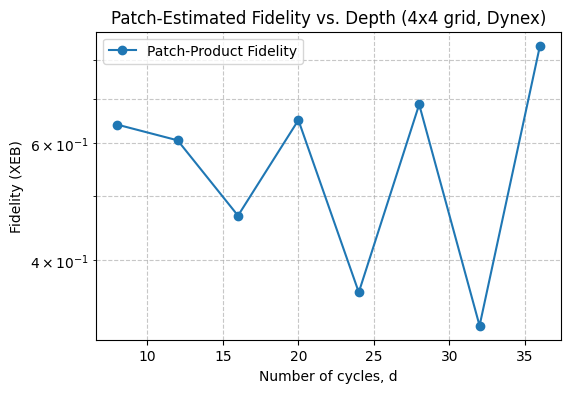

All measurements have been saved to 'all_measurements.txt'


In [9]:
# Plot results if we have data
if patch_products:
    depths = [d for d, _ in patch_products]
    vals = [v for _, v in patch_products]

    plt.figure(figsize=(6, 4))
    plt.semilogy(depths, vals, 'o-', label='Patch-Product Fidelity')
    plt.xlabel("Number of cycles, d")
    plt.ylabel("Fidelity (XEB)")
    plt.title("Patch-Estimated Fidelity vs. Depth (4x4 grid, Dynex)")
    plt.grid(True, which='both', linestyle='--', alpha=0.7)
    plt.legend()
    plt.savefig('dynex_xeb_results.png')
    plt.show()

    # Save all measurements to a JSON file
    with open('all_measurements.txt', 'w') as f:
        print(all_measurements, file=f)
    print("All measurements have been saved to 'all_measurements.txt'")
else:
    print("No data collected to plot")()